# XAI Question Validation Notebook
This notebook is used to validate the 10 planner questions implementation end-to-end. For now, it contains **Q1 only** (Local SHAP explanation).

## Q1 Scope
Question: **Why is the system recommending a reorder for this SKU right now?**

Validation outputs in this notebook:
1. Single-SKU forecast value
2. Local SHAP values
3. Top contributing features table
4. Natural-language explanation text
5. SHAP waterfall plot

In [1]:
from pathlib import Path
import sys

import joblib
import pandas as pd
import shap

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.xai.local_shap import (
    compute_local_shap,
    get_top_contributors,
    generate_local_explanation_text,
)

MODEL_PATH = ROOT / 'artifacts' / 'models' / 'tuned_lgbm_28.joblib'
DATA_PATH = ROOT / 'data' / 'processed' / 'lgbm_28' / 'test.csv'

print('MODEL_PATH:', MODEL_PATH)
print('DATA_PATH:', DATA_PATH)

c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MODEL_PATH: C:\Users\amrok\Desktop\Thesis\Project_XAI\xai-retail-replenishment\artifacts\models\tuned_lgbm_28.joblib
DATA_PATH: C:\Users\amrok\Desktop\Thesis\Project_XAI\xai-retail-replenishment\data\processed\lgbm_28\test.csv


In [2]:
model = joblib.load(MODEL_PATH)
test_df = pd.read_csv(DATA_PATH)

target_col = 'aggregated_sales_28'
feature_cols = [c for c in test_df.columns if c != target_col]
X_test = test_df[feature_cols].copy()

print('Rows:', len(X_test), 'Feature cols:', len(feature_cols))
print('Sample feature columns:', feature_cols[:8])

Rows: 15807 Feature cols: 39
Sample feature columns: ['item_id', 'date', 'is_month_end', 'sales_lag_28', 'sales_lag_14', 'sales_lag_7', 'sales_lag_1', 'sales_lag_2']


In [3]:
# Choose one SKU row for Q1 validation.
sample_idx = 0
sku_id = str(X_test.iloc[sample_idx]['item_id']) if 'item_id' in X_test.columns else f'row_{sample_idx}'

forecast_value = float(model.predict(X_test.iloc[[sample_idx]])[0])

local_sv = compute_local_shap(model=model, X=X_test, idx=sample_idx)
top_df = get_top_contributors(local_sv, n=8)
q1_text = generate_local_explanation_text(
    shap_values=local_sv,
    forecast_value=forecast_value,
    sku_id=sku_id,
)

print('SKU:', sku_id)
print('Forecast:', round(forecast_value, 4))

c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\e

[LightGBM] [Warning] feature_fraction is set=0.9828160165372797, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9828160165372797
[LightGBM] [Warning] bagging_fraction is set=0.9041986740582306, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9041986740582306
SKU: FOODS_1_001
Forecast: 19.6835


In [4]:
# Basic integrity checks for Q1 output contract.
required_cols = {'feature', 'shap_value', 'feature_value'}
if not required_cols.issubset(set(top_df.columns)):
    raise ValueError(f'Missing required Q1 columns: {required_cols - set(top_df.columns)}')
if len(top_df) == 0:
    raise ValueError('Top contributors output is empty.')
if not isinstance(q1_text, str) or len(q1_text.strip()) == 0:
    raise ValueError('Q1 generated explanation text is empty.')

display(top_df)
print('\nQ1 Explanation:')
print(q1_text)

,feature,shap_value,feature_value
0,num__sales_lag_7,-41.455523,19.000000
1,num__sales_roll_mean_14,4.560392,17.500000
2,num__item_mean_train,-3.796539,16.911111
3,num__sales_roll_mean_28,3.097603,14.250000
4,num__sales_lag_28,0.697965,10.000000
5,num__sales_lag_14,0.548499,16.000000
6,num__item_std_train,-0.524078,3.356285
7,num__sales_lag_1,-0.507824,19.000000



Q1 Explanation:
SKU: FOODS_1_001
Forecast (next 28 days): 19.7 units (20)
This SKU's typical demand: ~16.9 units/period
Forecast is 16.4% above historical average -> elevated demand expected.
Recent trend: upward (14-day avg 17.5, 28-day avg 14.2)
No active promotions detected. Recent event signals in the 28-day lookback: event_valentines_day_28.


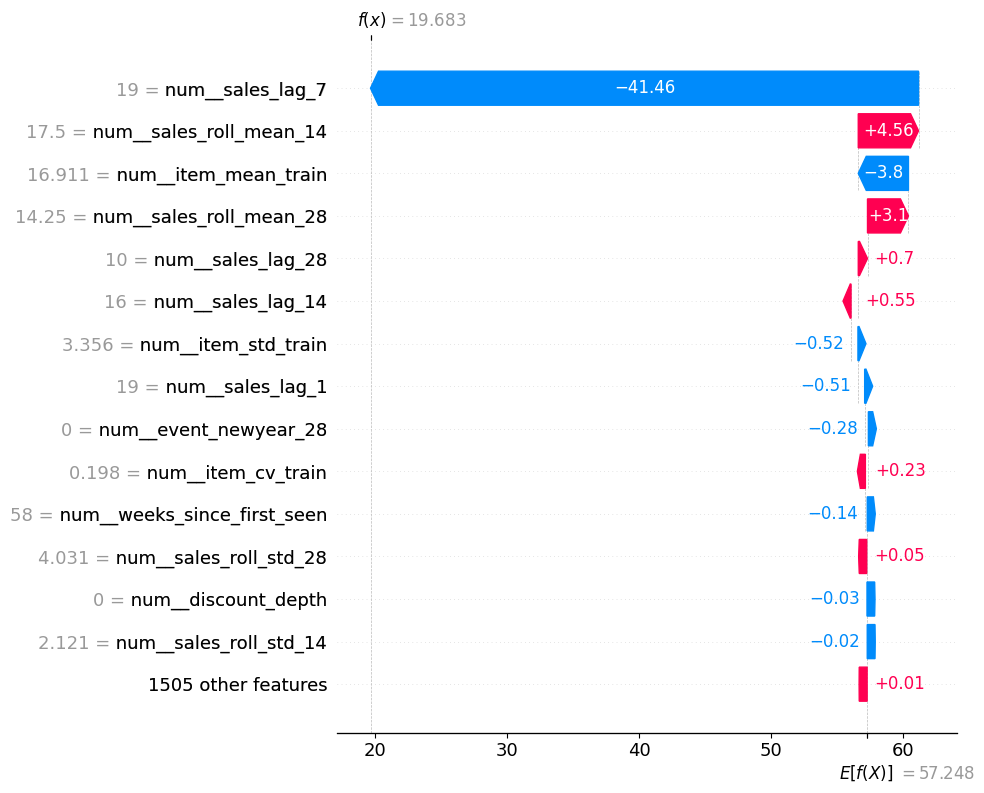

In [5]:
# Waterfall chart for local SHAP explanation.
shap.plots.waterfall(local_sv, max_display=15)

In [6]:
# Optional artifact save for tracking Q1 validation output.
REPORTS_DIR = ROOT / 'artifacts' / 'reports'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

q1_table_path = REPORTS_DIR / 'q1_local_shap_top_contributors_sample_28d.csv'
top_df.to_csv(q1_table_path, index=False)

print('Saved Q1 top contributors sample to:', q1_table_path)

Saved Q1 top contributors sample to: C:\Users\amrok\Desktop\Thesis\Project_XAI\xai-retail-replenishment\artifacts\reports\q1_local_shap_top_contributors_sample_28d.csv


## Q1 Re-Run for FOODS_1_002
Run the same local SHAP validation for a different SKU to compare behavior with FOODS_1_001.

In [12]:
# Select FOODS_1_002 and use its most recent row in test data
sku_id_2 = 'FOODS_1_002'
mask_2 = X_test['item_id'] == sku_id_2
if not mask_2.any():
    raise ValueError(f'{sku_id_2} not found in test set.')

sample_idx_2 = X_test[mask_2].index[-1]

forecast_value_2 = float(model.predict(X_test.loc[[sample_idx_2]])[0])
local_sv_2 = compute_local_shap(model=model, X=X_test, idx=sample_idx_2)
top_df_2 = get_top_contributors(local_sv_2, n=8)
q1_text_2 = generate_local_explanation_text(
    shap_values=local_sv_2,
    forecast_value=forecast_value_2,
    sku_id=sku_id_2,
)

print('SKU:', sku_id_2)
print('Selected row idx:', sample_idx_2)
print('Forecast:', round(forecast_value_2, 4))

c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] feature_fraction is set=0.9828160165372797, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9828160165372797
[LightGBM] [Warning] bagging_fraction is set=0.9041986740582306, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9041986740582306
SKU: FOODS_1_002
Selected row idx: 21
Forecast: 12.2207


,feature,shap_value,feature_value
0,num__sales_lag_7,-48.594903,11.000000
1,num__sales_roll_mean_14,5.175382,10.500000
2,num__item_mean_train,-4.293253,12.266667
3,num__sales_roll_mean_28,3.226676,11.750000
4,num__sales_lag_1,-0.575030,11.000000
5,num__sales_lag_28,0.547941,14.000000
6,num__event_newyear_28,-0.511345,0.000000
7,num__sales_lag_14,0.491841,10.000000



Q1 Explanation (FOODS_1_002):
SKU: FOODS_1_002
Forecast (next 28 days): 12.2 units (13)
This SKU's typical demand: ~12.3 units/period
Forecast is 0.4% below historical average -> stable demand expected.
Recent trend: softening (14-day avg 10.5, 28-day avg 11.8)
No active promotions or events detected.


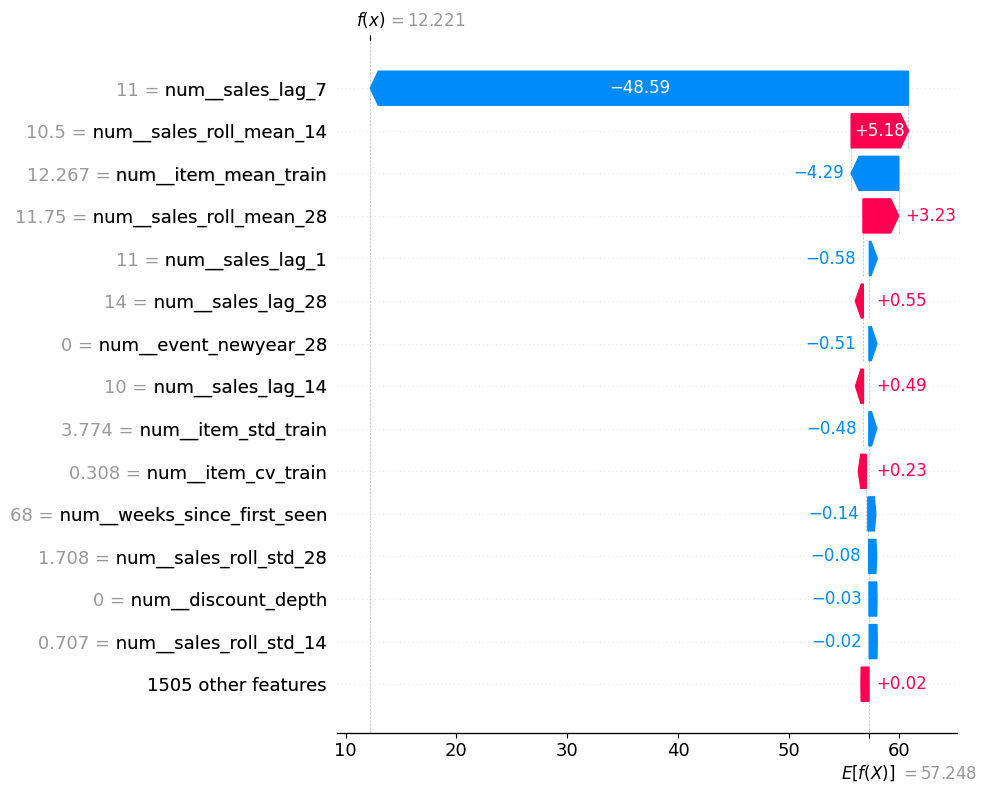


Saved Q1 top contributors for FOODS_1_002 to: C:\Users\amrok\Desktop\Thesis\Project_XAI\xai-retail-replenishment\artifacts\reports\q1_local_shap_top_contributors_FOODS_1_002_28d.csv


In [16]:
display(top_df_2)
print('\nQ1 Explanation (FOODS_1_002):')
print(q1_text_2)

shap.plots.waterfall(local_sv_2, max_display=15)

reports_dir_2 = ROOT / 'artifacts' / 'reports'
reports_dir_2.mkdir(parents=True, exist_ok=True)
q1_table_path_2 = reports_dir_2 / 'q1_local_shap_top_contributors_FOODS_1_002_28d.csv'
top_df_2.to_csv(q1_table_path_2, index=False)
print('\nSaved Q1 top contributors for FOODS_1_002 to:', q1_table_path_2)

In [13]:
from pathlib import Path
import pandas as pd

if 'df' in globals():
    _base_df = df.copy()
elif 'test_df' in globals():
    _base_df = test_df.copy()
else:
    _root = Path('..').resolve()
    _base_df = pd.read_csv(_root / 'data' / 'processed' / 'lgbm_28' / 'test.csv')

if 'sample_idx_2' not in globals():
    raise ValueError('sample_idx_2 is not defined. Run the FOODS_1_002 Q1 cell first.')

print('shap_row_idx_2:', sample_idx_2)
context_row_2 = _base_df.loc[sample_idx_2]
print(context_row_2[['sales_roll_mean_14', 'sales_roll_mean_28', 'sales_lag_7']])

shap_row_idx_2: 21
sales_roll_mean_14     10.5
sales_roll_mean_28    11.75
sales_lag_7            11.0
Name: 21, dtype: object


In [15]:
from pathlib import Path
import pandas as pd

if 'df' in globals():
    _base_df = df.copy()
elif 'test_df' in globals():
    _base_df = test_df.copy()
else:
    _root = Path('..').resolve()
    _base_df = pd.read_csv(_root / 'data' / 'processed' / 'lgbm_28' / 'test.csv')

if 'sample_idx_2' not in globals():
    raise ValueError('sample_idx_2 is not defined. Run the FOODS_1_002 Q1 cell first.')

context_row_2 = _base_df.loc[sample_idx_2]

forecast_for_check = float(globals().get('forecast_value_2', 12.221))

print('shap_row_idx_2:', sample_idx_2)
print('item_mean_train (SHAP row):', round(float(context_row_2['item_mean_train']), 3))
print('roll_mean_14 (SHAP row):', round(float(context_row_2['sales_roll_mean_14']), 3))
print('roll_mean_28 (SHAP row):', round(float(context_row_2['sales_roll_mean_28']), 3))
print('lag_7 (SHAP row):', float(context_row_2['sales_lag_7']))
print('forecast:', round(forecast_for_check, 3))
print('pct vs mean:', round((forecast_for_check - float(context_row_2['item_mean_train'])) / float(context_row_2['item_mean_train']) * 100, 1))

shap_row_idx_2: 21
item_mean_train (SHAP row): 12.267
roll_mean_14 (SHAP row): 10.5
roll_mean_28 (SHAP row): 11.75
lag_7 (SHAP row): 11.0
forecast: 12.221
pct vs mean: -0.4
